In [ ]:
!pip install datasets
!pip install torchtext
!pip install tqdm


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.4/491.4 kB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.6/193.6 kB 23.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 23.5 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.2
    Uninstalling fsspec-2025.3.2:
      Successfully uninstalled fsspec-2025.3.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch 2.6.0+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cublas-cu12 12.5.3.2 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cuda-cupti-cu12==12.4.127; platform_system 

In [ ]:
!pip install torch==2.3.0 torchtext==0.18.0


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 779.2/779.2 MB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 128.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 107.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 68.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 20.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 45.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.0/196.0 MB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.2/176.2 MB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.1/99.1 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
import collections

import datasets
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torchtext.data import get_tokenizer
from torchtext.vocab import build_vocab_from_iterator
import torchtext
import tqdm

/usr/local/lib/python3.11/dist-packages/torchtext/data/__init__.py:4: UserWarning: 
/!\ IMPORTANT WARNING ABOUT TORCHTEXT STATUS /!\ 
Torchtext is deprecated and the last released version will be 0.18 (this one). You can silence this warning by calling the following at the beginnign of your scripts: `import torchtext; torchtext.disable_torchtext_deprecation_warning()`
  warnings.warn(torchtext._TORCHTEXT_DEPRECATION_MSG)
/usr/local/lib/python3.11/dist-packages/torchtext/vocab/__init__.py:4: UserWarning: 
/!\ IMPORTANT WARNING ABOUT TORCHTEXT STATUS /!\ 
Torchtext is deprecated and the last released version will be 0.18 (this one). You can silence this warning by calling the following at the beginnign of your scripts: `import torchtext; torchtext.disable_torchtext_deprecation_warning()`
  warnings.warn(torchtext._TORCHTEXT_DEPRECATION_MSG)
/usr/local/lib/python3.11/dist-packages/torchtext/utils.py:4: UserWarning: 
/!\ IMPORTANT WARNING ABOUT TORCHTEXT STATUS /!\ 
Torchtext is deprecated

In [ ]:
#setting the seed for reproducibility
seed = 1234

np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.backends.cudnn.deterministic = True

In [ ]:
train_data, test_data = datasets.load_dataset("imdb", split=["train", "test"]) #loads and creates training and testing sets

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/7.81k [00:00<?, ?B/s]

train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

unsupervised-00000-of-00001.parquet:   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

In [ ]:
tokenizer = get_tokenizer("basic_english") #initilizes a tokenizer

In [ ]:
def tokenize_example(example, tokenizer, max_length): # this funciton is a tokenizing pre processing step.
    tokens = tokenizer(example["text"])[:max_length] #applies the tokenizer to the text
    length = len(tokens) #gets the legnth of the tokens
    return {"tokens": tokens, "length": length}

In [ ]:
max_length = 256
#applies tokenize_example to every example in the training and testing data.

train_data = train_data.map(
    tokenize_example, fn_kwargs={"tokenizer": tokenizer, "max_length": max_length}
)
test_data = test_data.map(
    tokenize_example, fn_kwargs={"tokenizer": tokenizer, "max_length": max_length}
)

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

In [ ]:
test_size = 0.25

train_valid_data = train_data.train_test_split(test_size=test_size)
train_data = train_valid_data["train"]
valid_data = train_valid_data["test"]

In [ ]:
min_freq = 5
special_tokens = ["<unk>", "<pad>"] # add special tokens

vocab = build_vocab_from_iterator( #maps each word to a unique integer ID
    train_data["tokens"],
    min_freq=min_freq,
    specials=special_tokens,
)

In [ ]:
unk_index = vocab["<unk>"] #used to represent words not in the vocabulary
pad_index = vocab["<pad>"] #pads sequences with a fixed lenght

In [ ]:
vocab.set_default_index(unk_index) #sets default index to unk_index

In [ ]:
def numericalize_example(example, vocab): #converts a tokenized example into a sequence of numerical IDs using the vocab object
    ids = vocab.lookup_indices(example["tokens"])
    return {"ids": ids}

In [ ]:
train_data = train_data.map(numericalize_example, fn_kwargs={"vocab": vocab}) # This code maps the numericalize_example function across your datasets, converting token lists to integer ID
valid_data = valid_data.map(numericalize_example, fn_kwargs={"vocab": vocab})
test_data = test_data.map(numericalize_example, fn_kwargs={"vocab": vocab})

Map:   0%|          | 0/18750 [00:00<?, ? examples/s]

Map:   0%|          | 0/6250 [00:00<?, ? examples/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

In [ ]:
train_data = train_data.with_format(type="torch", columns=["ids", "label", "length"]) #selects only the columns needed for pytorch training
valid_data = valid_data.with_format(type="torch", columns=["ids", "label", "length"])
test_data = test_data.with_format(type="torch", columns=["ids", "label", "length"])

In [ ]:
train_data[0] #visualize an entry of the training data

{'label': tensor(1),
 'length': tensor(135),
 'ids': tensor([  180,     4,    14,    10,   191,   841,    34,     7,     2,   121,
            98,   816,    50,     8,  1516,     2,   380,     7,     2,   184,
             3,     8,   805,    14,    18,    10,     8,   805,  2246,   429,
             3,    12,   347,    15,     2,   388,  1025,     9,    16,    76,
             5,    64,     7, 11198,     3,     2,  9212,    17,   761,     4,
          7812,  5460,   198,    37,     4,     6,  3653,  3683,    17,   226,
             5, 11893,     3,    53,     7,    15,  3310,   354,     5,   689,
             4,     0,  5471,     3,  2706,  3826,     9,    16,   246,    13,
            14,    18,  1111,    33,    17,   126,   188,     8,    35,   597,
           181,    19,     5,    34,  3942,  1381,    13,     2,  5370,     3,
            32,  4228,    10,    41,  2825,     8,    37,     3,     2,  4411,
          1141,   213,  2655,     6, 16946,  3729,   590,  4845,     8,  2416,


In [ ]:
def get_collate_fn(pad_index): #Takes the pad_index as input which tells pad_sequence what value to use when padding shorter sequences
    def collate_fn(batch):
        batch_ids = [i["ids"] for i in batch]
        batch_ids = nn.utils.rnn.pad_sequence(
            batch_ids, padding_value=pad_index, batch_first=True #pads the token ID sequences to the length of the longest in the batch
        )
        batch_length = [i["length"] for i in batch] #Stacks the sequence lengths into a tensor.
        batch_length = torch.stack(batch_length)
        batch_label = [i["label"] for i in batch]
        batch_label = torch.stack(batch_label)
        batch = {"ids": batch_ids, "length": batch_length, "label": batch_label}
        return batch

    return collate_fn

In [ ]:
def get_data_loader(dataset, batch_size, pad_index, shuffle=False):
    collate_fn = get_collate_fn(pad_index) #uses the collate function to handle padding by batch
    data_loader = torch.utils.data.DataLoader(
        dataset=dataset,
        batch_size=batch_size,
        collate_fn=collate_fn,
        shuffle=shuffle,
    )
    return data_loader #returns a data loader

In [ ]:
batch_size = 256

#sets up data loaders for training, validation, and testing
train_data_loader = get_data_loader(train_data, batch_size, pad_index, shuffle=True)
valid_data_loader = get_data_loader(valid_data, batch_size, pad_index)
test_data_loader = get_data_loader(test_data, batch_size, pad_index)

In [ ]:
import torch
import torch.nn as nn
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence

class LSTM(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim,
                 num_layers=1, bidirectional=False, dropout=0.1, pad_index=0): #define LSTM model
        super(LSTM, self).__init__()

        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=pad_index) #Converts token indices into dense vectors.



        self.lstm = nn.LSTM( # a standard LSTM that provides support for multiple layers, bidirecitonal nodes, and batch-first inputs
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            bidirectional=bidirectional,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        #Projects the final hidden state to the desired number of output classes
        self.fc = nn.Linear(hidden_dim * (2 if bidirectional else 1), output_dim)

    def forward(self, input_ids, lengths):
    # input_ids: (batch_size, seq_len)
    # lengths: (batch_size)

      embedded = self.embedding(input_ids)  # (batch_size, seq_len, embedding_dim)

      # pack the padded sequences
      packed_embedded = pack_padded_sequence(embedded, lengths.cpu(), batch_first=True, enforce_sorted=False)
      packed_output, (hidden, cell) = self.lstm(packed_embedded)

      # for bidirectional LSTM, concatenate final forward and backward hidden states
      if self.lstm.bidirectional:
          hidden = torch.cat((hidden[-2], hidden[-1]), dim=1)  # (batch_size, hidden_dim * 2)
      else:
          hidden = hidden[-1]  # (batch_size, hidden_dim)

      output = self.fc(hidden)  # (batch_size, output_dim)
      return output


In [ ]:
# model hyperparameters
vocab_size = len(vocab)  #total number of unique tokens in the vocabulary
embedding_dim = 300      # Size of word embeddings
hidden_dim = 300         # Hidden size of LSTM
output_dim = len(train_data.unique("label"))  # Number of output classes
n_layers = 2             # Number of LSTM layers
bidirectional = True     # Use bidirectional LSTM
dropout_rate = 0.5       # Dropout between LSTM layers

# Instantiate the model
model = LSTM(
    vocab_size,
    embedding_dim,
    hidden_dim,
    output_dim,
    n_layers,
    bidirectional,
    dropout_rate,
    pad_index,  # padding index for embedding
)

# Move model to GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)


In [ ]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)  # Sum the number of elements for each parameter in the model and only include those with requires_grad=True (i.e., parameters that will be updated during training)


print(f"The model has {count_parameters(model):,} trainable parameters")

The model has 10,101,302 trainable parameters


In [ ]:
def initialize_weights(m):
    if isinstance(m, nn.Linear):     # if the layer is a fully connected layer
        nn.init.xavier_normal_(m.weight) # initialize xavier for weights
        nn.init.zeros_(m.bias)         # Initialize biases to zero
    elif isinstance(m, nn.LSTM):
        for name, param in m.named_parameters():
            if "bias" in name:
                nn.init.zeros_(param)                 # Initialize all LSTM biases to zero
            elif "weight" in name:
                nn.init.orthogonal_(param) # Orthogonal initialization for LSTM weights

In [ ]:
model.apply(initialize_weights) #Calls initialize_weights for each module

LSTM(
  (embedding): Embedding(21635, 300, padding_idx=1)
  (lstm): LSTM(300, 300, num_layers=2, batch_first=True, dropout=0.5, bidirectional=True)
  (fc): Linear(in_features=600, out_features=2, bias=True)
)

In [ ]:
vectors = torchtext.vocab.GloVe() # Load pre-trained GloVe word vectors

In [ ]:
pretrained_embedding = vectors.get_vecs_by_tokens(vocab.get_itos()) # get embedding vectors for your vocabulary words

In [ ]:
model.embedding.weight.data = pretrained_embedding # assign pre-trained GloVe embeddings to the model's embedding layer


In [ ]:
lr = 5e-4 # # Set learning rate
## Initialize Adam optimizer for all model parameters
optimizer = optim.Adam(model.parameters(), lr=lr)

In [ ]:
criterion = nn.CrossEntropyLoss() #cross entropy loss

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

device #switch to GPU

device(type='cuda')

In [ ]:
model = model.to(device) #save the model to GPU
criterion = criterion.to(device)

In [ ]:
def train(dataloader, model, criterion, optimizer, device):
    model.train() # Set the model to training mode
    epoch_losses = [] # Track losses for the epoch
    epoch_accs = [] # Track accuracies for the epoch
    for batch in tqdm.tqdm(dataloader, desc="training..."): #load batches
        ids = batch["ids"].to(device)         # Move input and target tensors to the GPU
        length = batch["length"]
        label = batch["label"].to(device)
        prediction = model(ids, length)         # Forward pass: compute predictions
        loss = criterion(prediction, label)         # Compute loss between prediction and true labels
        accuracy = get_accuracy(prediction, label)         # Compute accuracy (assumes you have a get_accuracy function)
        optimizer.zero_grad() # Clear gradients from previous step
        loss.backward() # Backpropagate the loss
        optimizer.step() # Update model weights
        epoch_losses.append(loss.item())         # Record this batch's loss and accuracy
        epoch_accs.append(accuracy.item())     # Return average loss and accuracy across the entire epoch
    return np.mean(epoch_losses), np.mean(epoch_accs)

In [ ]:
def evaluate(dataloader, model, criterion, device):
    model.eval() ## Set model to evaluation mode
    epoch_losses = [] ## List to store batch losses
    epoch_accs = []  # List to store batch accuracies
    with torch.no_grad(): # Disable gradient computation
        for batch in tqdm.tqdm(dataloader, desc="evaluating..."):
            ids = batch["ids"].to(device) # Move tensors to the appropriate device
            length = batch["length"]
            label = batch["label"].to(device)
            prediction = model(ids, length) #forward pass
            loss = criterion(prediction, label) # compute loss and accuracy for the batch
            accuracy = get_accuracy(prediction, label)
            epoch_losses.append(loss.item())
            epoch_accs.append(accuracy.item())             # Store metrics

    return np.mean(epoch_losses), np.mean(epoch_accs)

In [ ]:
def get_accuracy(prediction, label):
    batch_size, _ = prediction.shape
    predicted_classes = prediction.argmax(dim=-1)     # Get the predicted class index for each example
    correct_predictions = predicted_classes.eq(label).sum()     # Compare predictions with true labels and count correct matches
    accuracy = correct_predictions / batch_size #compute accuarcy
    return accuracy

In [ ]:
n_epochs = 10 # Number of training epochs
best_valid_loss = float("inf") # Initialize best validation loss to infinity

metrics = collections.defaultdict(list) # Dictionary to track losses and accuracies across epochs

# Loop over each epoch


for epoch in range(n_epochs):
      # Train for one epoch and get average training loss and accuracy

    train_loss, train_acc = train(
        train_data_loader, model, criterion, optimizer, device
    )
        # Evaluate on validation set

    valid_loss, valid_acc = evaluate(valid_data_loader, model, criterion, device)
        # Save metrics for plotting or logging

    metrics["train_losses"].append(train_loss)
    metrics["train_accs"].append(train_acc)
    metrics["valid_losses"].append(valid_loss)
    metrics["valid_accs"].append(valid_acc)
        # Save the model if validation loss improves

    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        torch.save(model.state_dict(), "lstm.pt")
            # Print epoch summary

    print(f"epoch: {epoch}")
    print(f"train_loss: {train_loss:.3f}, train_acc: {train_acc:.3f}")
    print(f"valid_loss: {valid_loss:.3f}, valid_acc: {valid_acc:.3f}")

evaluating...: 100%|██████████| 25/25 [00:00<00:00, 25.72it/s]


epoch: 0
train_loss: 0.534, train_acc: 0.720
valid_loss: 0.404, valid_acc: 0.824


evaluating...: 100%|██████████| 25/25 [00:00<00:00, 25.53it/s]


epoch: 1
train_loss: 0.368, train_acc: 0.841
valid_loss: 0.367, valid_acc: 0.853


evaluating...: 100%|██████████| 25/25 [00:00<00:00, 25.48it/s]


...

epoch: 7
train_loss: 0.126, train_acc: 0.956
valid_loss: 0.354, valid_acc: 0.868


evaluating...: 100%|██████████| 25/25 [00:00<00:00, 25.66it/s]


epoch: 8
train_loss: 0.093, train_acc: 0.970
valid_loss: 0.441, valid_acc: 0.859


evaluating...: 100%|██████████| 25/25 [00:00<00:00, 25.51it/s]

epoch: 9
train_loss: 0.082, train_acc: 0.974
valid_loss: 0.484, valid_acc: 0.865


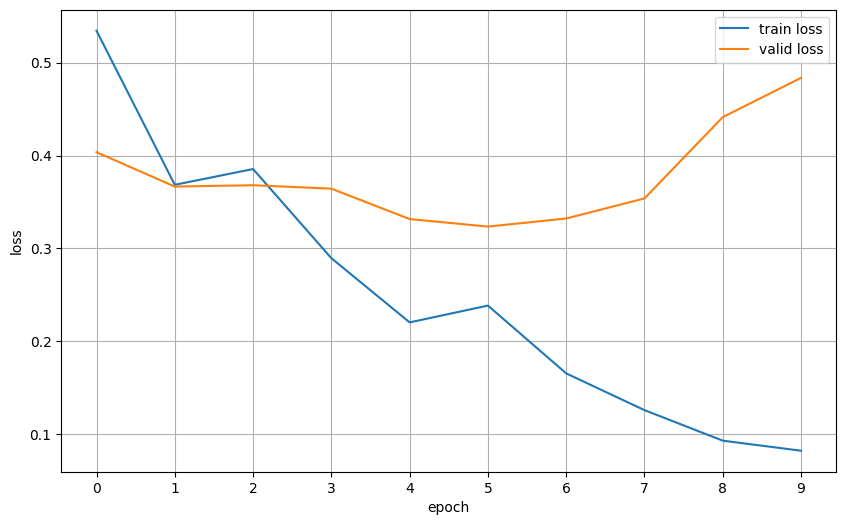

In [ ]:
fig = plt.figure(figsize=(10, 6)) # Create a figure and one subplot

ax = fig.add_subplot(1, 1, 1)
ax.plot(metrics["train_losses"], label="train loss") # Plot training and validation loss curves
ax.plot(metrics["valid_losses"], label="valid loss")
ax.set_xlabel("epoch") # Label the axes

ax.set_ylabel("loss")
ax.set_xticks(range(n_epochs))
ax.legend() # Add legend and grid for readability

ax.grid()

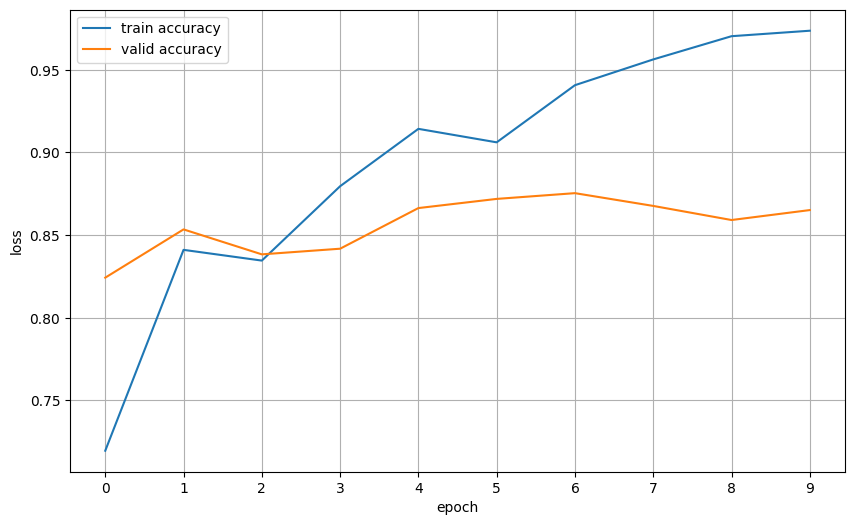

In [ ]:
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(1, 1, 1)
ax.plot(metrics["train_accs"], label="train accuracy") # Plot training and validation accuracy

ax.plot(metrics["valid_accs"], label="valid accuracy")
ax.set_xlabel("epoch") # Label axes correctly

ax.set_ylabel("loss")
ax.set_xticks(range(n_epochs)) # Match x-ticks to the number of epochs

ax.legend()# Add legend and grid

ax.grid()

In [ ]:
model.load_state_dict(torch.load("lstm.pt")) # Load the best model weights saved during training


test_loss, test_acc = evaluate(test_data_loader, model, criterion, device) # Evaluate on the test dataset


evaluating...: 100%|██████████| 98/98 [00:03<00:00, 25.13it/s]


In [ ]:
print(f"test_loss: {test_loss:.3f}, test_acc: {test_acc:.3f}")

test_loss: 0.361, test_acc: 0.856


In [ ]:
def predict_sentiment(text, model, tokenizer, vocab, device):
    # Tokenize the input text
    tokens = tokenizer(text)
    # Convert tokens to vocabulary indices
    ids = vocab.lookup_indices(tokens)
    # Create a tensor for sequence length
    length = torch.LongTensor([len(ids)])
    # Convert ids to tensor and add batch dimension
    tensor = torch.LongTensor(ids).unsqueeze(dim=0).to(device)
    # Run the model to get raw logits
    prediction = model(tensor, length).squeeze(dim=0)
    # Apply softmax to get class probabilities
    probability = torch.softmax(prediction, dim=-1)

    # Get predicted class index
    predicted_class = prediction.argmax(dim=-1).item()

    # Get probability associated with the predicted class
    predicted_probability = probability[predicted_class].item()

    return predicted_class, predicted_probability


In [ ]:
text = "This film is terrible!" #apply the predict_sentiment function

predict_sentiment(text, model, tokenizer, vocab, device)

(0, 0.9644745588302612)

In [ ]:
text = "This film is great!"

predict_sentiment(text, model, tokenizer, vocab, device)

(1, 0.9821133017539978)

In [ ]:
text = "This film is not terrible, it's great!"

predict_sentiment(text, model, tokenizer, vocab, device)

(0, 0.8659369349479675)

In [ ]:
text = "This film is not great, it's terrible!"

predict_sentiment(text, model, tokenizer, vocab, device)

(0, 0.7918088436126709)